# SimCLR Self-Supervised Learning for Metal Surface Defect Classification

This notebook implements the self-supervised SimCLR stage of the research methodology using the NEU-DET dataset.

Pipeline:

NEU-DET → Augmentation → Two Views → Encoder → Representation → Projection Head → NT-Xent Contrastive Loss

**Import the required libraries**

In [ ]:
import os
import glob
import random

import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## 1. Load NEU-DET Dataset

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Dataset path**

In [ ]:
dataset_path = "/content/drive/MyDrive/NEU-DET/train/images"

print("Dataset path:", dataset_path)

Dataset path: /content/drive/MyDrive/NEU-DET/train/images


Verify dataset

In [ ]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

image_paths = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_paths.append(os.path.join(root, file))

print("Total images found:", len(image_paths))

if len(image_paths) > 0:
    print("First image:", image_paths[0])

Total images found: 1440
First image: /content/drive/MyDrive/NEU-DET/train/images/inclusion/inclusion_116.jpg


Look at one image

Image shape: (200, 200, 3)


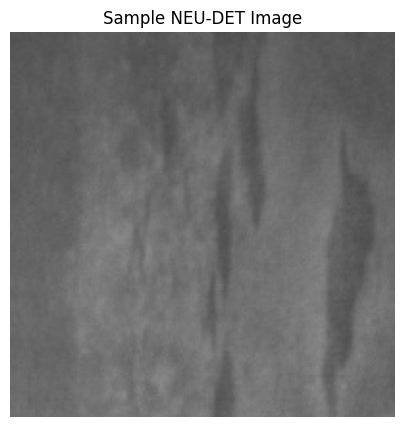

In [ ]:
sample_image = cv2.imread(image_paths[0])

sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

print("Image shape:", sample_image.shape)

plt.figure(figsize=(5, 5))
plt.imshow(sample_image)
plt.axis("off")
plt.title("Sample NEU-DET Image")
plt.show()

SimCLR augmentation

## 2. SimCLR Augmentation Pipeline

For each original image, two different augmented views are generated.

The two views are treated as a positive pair during contrastive learning.

In [ ]:
simclr_transform = transforms.Compose([
    transforms.ToPILImage(),

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.8, 1.0)
    ),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.4,
        hue=0.1
    ),

    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=23)],
        p=0.5
    ),

    transforms.ToTensor()
])

Generate two views

In [ ]:
image = cv2.imread(image_paths[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

view1 = simclr_transform(image)
view2 = simclr_transform(image)

print("View 1 shape:", view1.shape)
print("View 2 shape:", view2.shape)

View 1 shape: torch.Size([3, 224, 224])
View 2 shape: torch.Size([3, 224, 224])


Visualize the two views

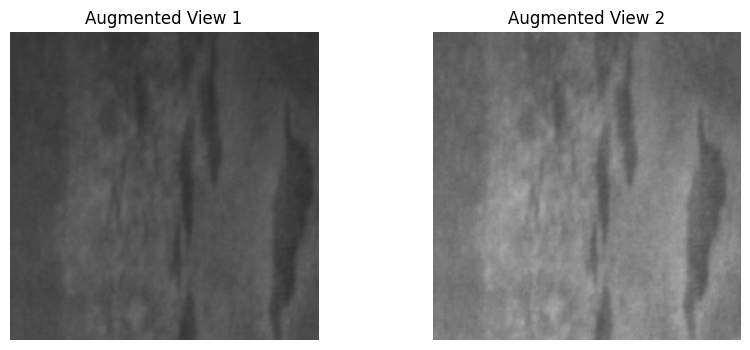

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(view1.permute(1, 2, 0))
plt.title("Augmented View 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(view2.permute(1, 2, 0))
plt.title("Augmented View 2")
plt.axis("off")

plt.show()

Create SimCLR Dataset

## 3. SimCLR Dataset

The dataset generates two independently augmented views from each original image.

In [ ]:
class SimCLRDataset(Dataset):

    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        image_path = self.image_paths[index]

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        view1 = self.transform(image)
        view2 = self.transform(image)

        return view1, view2

Create dataset

In [ ]:
simclr_dataset = SimCLRDataset(
    image_paths=image_paths,
    transform=simclr_transform
)

print("Number of samples:", len(simclr_dataset))

Number of samples: 1440


Create DataLoader

In [ ]:
batch_size = 32

simclr_loader = DataLoader(
    simclr_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Batch size:", batch_size)

Batch size: 32


Check one batch

In [ ]:
view1_batch, view2_batch = next(iter(simclr_loader))

print("View 1 batch shape:", view1_batch.shape)
print("View 2 batch shape:", view2_batch.shape)

View 1 batch shape: torch.Size([32, 3, 224, 224])
View 2 batch shape: torch.Size([32, 3, 224, 224])


Import ResNet

In [ ]:
import torchvision.models as models

# SimCLR Model

We use ResNet-18 as the encoder and add a projection head, following the SimCLR methodology.

In [ ]:
class SimCLR(nn.Module):

    def __init__(self, projection_dim=128):
        super(SimCLR, self).__init__()

        # ResNet-18 encoder
        self.encoder = models.resnet18(weights=None)

        # Number of features before the original classification layer
        num_features = self.encoder.fc.in_features

        # Remove ImageNet classification layer
        self.encoder.fc = nn.Identity()

        # SimCLR projection head
        self.projector = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):

        # Encoder representation
        features = self.encoder(x)

        # Projection used for contrastive learning
        projections = self.projector(features)

        return features, projections

Initialize Model

In [ ]:
projection_dim = 128

model = SimCLR(
    projection_dim=projection_dim
).to(device)

print("Model initialized successfully.")
print("Device:", device)

Model initialized successfully.
Device: cuda


Test Model With One Batch

In [ ]:
view1_batch = view1_batch.to(device)
view2_batch = view2_batch.to(device)

with torch.no_grad():

    features1, projections1 = model(view1_batch)
    features2, projections2 = model(view2_batch)

print("Feature shape:", features1.shape)
print("Projection shape:", projections1.shape)

Feature shape: torch.Size([32, 512])
Projection shape: torch.Size([32, 128])


# NT-Xent Contrastive Loss

Define NT-Xent Loss


In [ ]:
class NTXentLoss(nn.Module):

    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()

        self.temperature = temperature

    def forward(self, z1, z2):

        batch_size = z1.size(0)

        # Normalize projections
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)

        # Combine both views
        representations = torch.cat([z1, z2], dim=0)

        # Cosine similarity
        similarity_matrix = torch.matmul(
            representations,
            representations.T
        )

        # Scale by temperature
        similarity_matrix = similarity_matrix / self.temperature

        # Remove self-similarity
        mask = torch.eye(
            2 * batch_size,
            device=similarity_matrix.device
        ).bool()

        similarity_matrix.masked_fill_(mask, -float("inf"))

        # Positive sample index
        targets = torch.arange(
            2 * batch_size,
            device=similarity_matrix.device
        )

        targets = (targets + batch_size) % (2 * batch_size)

        # Cross entropy
        loss = F.cross_entropy(
            similarity_matrix,
            targets
        )

        return loss

Create Loss Function

In [ ]:
temperature = 0.5

criterion = NTXentLoss(
    temperature=temperature
)

print("Temperature:", temperature)

Temperature: 0.5


#SimCLR Training

Optimizer

In [ ]:
learning_rate = 0.001

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

print("Learning rate:", learning_rate)

Learning rate: 0.001


Training Configuration

In [ ]:
num_epochs = 50

loss_history = []

print("Number of epochs:", num_epochs)
print("Number of training samples:", len(simclr_dataset))

Number of epochs: 50
Number of training samples: 1440


SimCLR Training Loop

In [ ]:
for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for view1, view2 in simclr_loader:

        # Move images to device
        view1 = view1.to(device, non_blocking=True)
        view2 = view2.to(device, non_blocking=True)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        _, z1 = model(view1)
        _, z2 = model(view2)

        # Contrastive loss
        loss = criterion(z1, z2)

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(simclr_loader)

    loss_history.append(epoch_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/50] Loss: 3.7538
Epoch [2/50] Loss: 3.5636
Epoch [3/50] Loss: 3.4442
Epoch [4/50] Loss: 3.3382
Epoch [5/50] Loss: 3.1726
Epoch [6/50] Loss: 3.1047
Epoch [7/50] Loss: 3.0893
Epoch [8/50] Loss: 3.0197
Epoch [9/50] Loss: 2.9449
Epoch [10/50] Loss: 2.9241
Epoch [11/50] Loss: 2.8851
Epoch [12/50] Loss: 2.8746
Epoch [13/50] Loss: 2.8199
Epoch [14/50] Loss: 2.7870
Epoch [15/50] Loss: 2.7619
Epoch [16/50] Loss: 2.7417
Epoch [17/50] Loss: 2.7041
Epoch [18/50] Loss: 2.7037
Epoch [19/50] Loss: 2.6598
Epoch [20/50] Loss: 2.6887
Epoch [21/50] Loss: 2.6443
Epoch [22/50] Loss: 2.6585
Epoch [23/50] Loss: 2.6456
Epoch [24/50] Loss: 2.6158
Epoch [25/50] Loss: 2.6043
Epoch [26/50] Loss: 2.6066
Epoch [27/50] Loss: 2.6039
Epoch [28/50] Loss: 2.5748
Epoch [29/50] Loss: 2.5676
Epoch [30/50] Loss: 2.5777
Epoch [31/50] Loss: 2.5469
Epoch [32/50] Loss: 2.5465
Epoch [33/50] Loss: 2.5314
Epoch [34/50] Loss: 2.5448
Epoch [35/50] Loss: 2.5293
Epoch [36/50] Loss: 2.5324
Epoch [37/50] Loss: 2.5332
Epoch [38/